# Lab 14 — Analog Modulation: AM, DSB, SSB, FM and FM Stereo

**Companion to Chapter 4** (*Analog Modulation and the Classic Radio*).
**Time needed:** about 90 minutes. **Difficulty:** introductory to core.

Analog modulation is where radio began, and it is still everywhere: AM broadcast, aviation voice
(AM on 118–137 MHz), amateur and military HF (SSB), FM broadcast with stereo and RDS, and analog
two-way radio. More importantly, every idea of digital communications first appeared here: the
complex envelope, coherent versus envelope detection, the power–bandwidth trade (FM), threshold
effects, and pilot-aided carrier recovery (FM stereo). This lab modulates and demodulates a
synthetic voice signal with each scheme, and builds a complete FM stereo transmitter and receiver.

### What you will learn
1. Generate AM with any modulation index, and demodulate it with a diode envelope detector and coherently.
2. Compare the spectra of AM, DSB-SC and SSB, and see what carrier phase errors do to DSB and SSB.
3. Predict an FM spectrum with Bessel functions and Carson's rule; demodulate with a discriminator and a PLL.
4. Measure FM's SNR advantage and its threshold.
5. Build the FM stereo multiplex (pilot at 19 kHz, L−R on 38 kHz) and measure stereo separation.

### Prerequisites
Lab 1 (complex baseband). Fourier transforms and the Hilbert transform (Chapter 2). Chapter 4.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | A voice-like test message | |
| 2 | AM and the envelope detector | yes |
| 3 | DSB-SC and SSB: spectra and phase errors | |
| 4 | FM: Bessel spectra and Carson's rule | yes |
| 5 | FM demodulation: discriminator and PLL | |
| 6 | The FM threshold | |
| 7 | FM stereo: the multiplex signal | |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, firwin, hilbert, resample_poly, butter, sosfiltfilt
from scipy.special import jv
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=14, lab="14")

Lab 14 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 14


## 1. A voice-like test message

A vowel is, to a first approximation, a periodic train of glottal pulses (the pitch, about 100–200 Hz)
filtered by the resonances of the vocal tract (the **formants**). We synthesise an "ah" with a pitch
that glides from 110 to 150 Hz and formants at 730, 1090 and 2440 Hz, sampled at 48 kHz and
band-limited to 4 kHz like a telephone/AM voice channel.

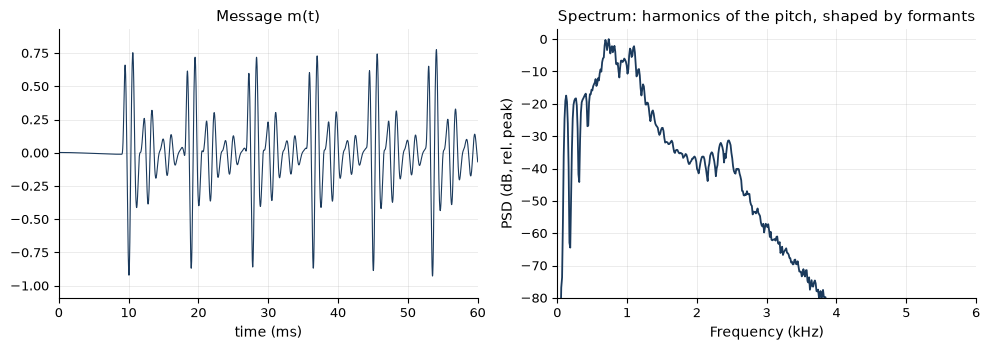

In [3]:
fa = 48_000
dur = 0.25
ta = np.arange(int(fa * dur)) / fa
pitch = 110 + 40 * ta / dur
phase = np.cumsum(pitch) / fa
glottal = (np.diff(np.floor(phase), prepend=0) > 0).astype(float)          # one pulse per pitch period
voice = glottal
for fmt, bw in [(730, 90), (1090, 110), (2440, 170)]:                      # formant resonators
    r = np.exp(-np.pi * bw / fa)
    voice = lfilter([1 - r], [1, -2 * r * np.cos(2 * np.pi * fmt / fa), r * r], voice)
voice = sosfiltfilt(butter(6, [80, 4000], btype="band", fs=fa, output="sos"), voice)
m = voice / np.max(np.abs(voice))                                           # peak-normalised message
f, ax = lk.fig("row2", 1, 2)
ax[0].plot(ta * 1e3, m, lw=0.8); ax[0].set_xlim(0, 60); ax[0].set_xlabel("time (ms)"); ax[0].set_title("Message m(t)")
lk.psd(ax[1], m, fa, 4096, scale=1e3, unit="kHz"); ax[1].set_xlim(0, 6); ax[1].set_ylim(-80, 3)
ax[1].set_title("Spectrum: harmonics of the pitch, shaped by formants")
lk.show(f)

## 2. AM and the envelope detector

Conventional AM (DSB with large carrier) transmits $s(t) = A_c[1 + \mu\,m(t)]\cos 2\pi f_c t$ with
$|m| \le 1$. While $\mu \le 1$ the envelope $A_c[1+\mu m(t)]$ never goes negative, so a **diode and an
RC filter** recover it: the capacitor charges to each carrier peak and discharges slowly between them.
The time constant must satisfy $1/f_c \ll RC \ll 1/W$: too short and the carrier ripple remains, too long
and the output cannot follow a falling envelope ("diagonal clipping"). The price of this simplicity is
power: the carrier carries no information, and the efficiency is $\eta = \mu^2 P_m/(1 + \mu^2 P_m)$,
at most 33% for a sine at $\mu = 1$ and far less for voice.

We simulate a real passband signal at $f_s$ = 480 kHz with a 60 kHz carrier.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

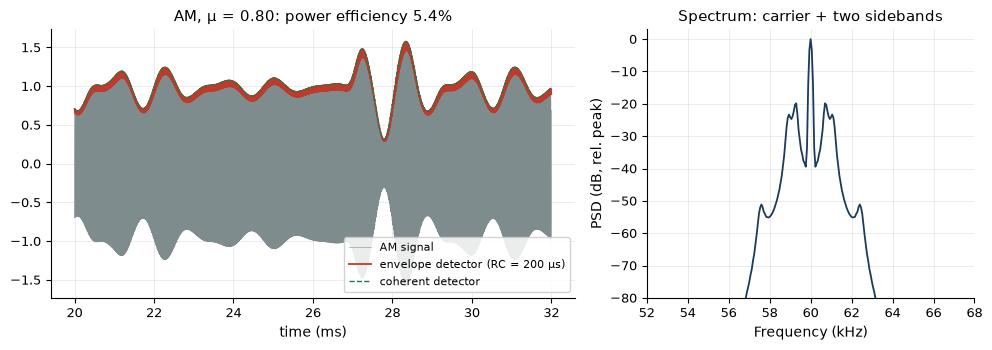

In [5]:
fs = 480_000
fc = 60_000
mp = resample_poly(m, fs // fa, 1)                       # message at the passband rate
t = np.arange(len(mp)) / fs

def envelope_detector(x, rc):
    """Ideal diode + RC: the capacitor follows rising peaks, decays as exp(-t/RC)."""
    a = np.exp(-1 / (rc * fs))
    y = np.empty_like(x); v = 0.0
    for i, xi in enumerate(x):
        v = xi if xi > v else v * a
        y[i] = v
    return y

def am_demo(mu=0.8, rc_us=200.0):
    s = (1 + mu * mp) * np.cos(2 * np.pi * fc * t)
    env = envelope_detector(s, rc_us * 1e-6)
    coh = sosfiltfilt(butter(6, 5000, fs=fs, output="sos"), 2 * s * np.cos(2 * np.pi * fc * t))
    f, ax = lk.fig("row2", 1, 2, gridspec_kw={"width_ratios": [1.6, 1]})
    sl = slice(int(0.02 * fs), int(0.032 * fs))
    ax[0].plot(t[sl] * 1e3, s[sl], color=lk.GRAY, lw=0.4, label="AM signal")
    ax[0].plot(t[sl] * 1e3, env[sl], color=lk.RED, lw=1.3, label=f"envelope detector (RC = {rc_us:.0f} µs)")
    ax[0].plot(t[sl] * 1e3, coh[sl], color=lk.GREEN, lw=1.0, ls="--", label="coherent detector")
    ax[0].set_xlabel("time (ms)"); ax[0].legend(fontsize=8, loc="lower right")
    eff = mu ** 2 * np.mean(mp ** 2) / (1 + mu ** 2 * np.mean(mp ** 2))
    ax[0].set_title(f"AM, μ = {mu:.2f}: power efficiency {eff * 100:.1f}%" + ("  (OVERMODULATED)" if mu > 1 else ""))
    lk.psd(ax[1], s, fs, 8192, scale=1e3, unit="kHz", color=lk.NAVY); ax[1].set_xlim(52, 68); ax[1].set_ylim(-80, 3)
    ax[1].set_title("Spectrum: carrier + two sidebands")
    lk.show(f)

lk.interact(am_demo, mu=lk.slider(0.8, 0.1, 1.5, 0.05, "modulation index μ"),
            rc_us=lk.slider(200, 10, 2000, 10, "RC (µs)"))

**What you should see.** At μ = 0.8 and RC = 200 µs the red envelope follows the message with a little
carrier ripple. Shrink RC to 20 µs: big ripple. Raise it to 1500 µs: the output lags behind falling
edges (diagonal clipping). Push μ above 1: the envelope folds over at the negative peaks and the envelope
detector output is distorted, while the coherent detector (green) is unaffected. The efficiency for
this voice signal is only a few percent.

### Try it yourself 2.1
What is the power efficiency (percent) of AM with a pure-tone message ($P_m = 1/2$) at μ = 0.5?

In [7]:
answer_2_1 = None
lk.check("2.1 AM efficiency, tone, μ = 0.5 (%)", answer_2_1, 100 * 0.125 / 1.125, atol=0.1)

[TODO] 2.1 AM efficiency, tone, μ = 0.5 (%): not attempted yet: replace the None with your answer

## 3. DSB-SC and SSB: spectra and phase errors

Suppressing the carrier (**DSB-SC**, $m(t)\cos 2\pi f_ct$) puts all the power into the sidebands but
requires a coherent receiver. Both sidebands carry the same information, so **SSB** sends only one:
$s_{\text{USB}}(t) = m(t)\cos 2\pi f_ct - \hat m(t)\sin 2\pi f_ct$, where $\hat m$ is the Hilbert transform.
Its complex envelope is the analytic signal $m + j\hat m$, which has no negative frequencies.

What a carrier **phase error** $\phi$ does differs: DSB output becomes $m\cos\phi$ (it fades away at 90°),
SSB output becomes $m\cos\phi \pm \hat m\sin\phi$ (same power, phase-distorted, and the ear barely
notices). A **frequency** error $\Delta f$ shifts every SSB audio component by $\Delta f$: the familiar
"Donald Duck" voice of a mistuned SSB receiver.

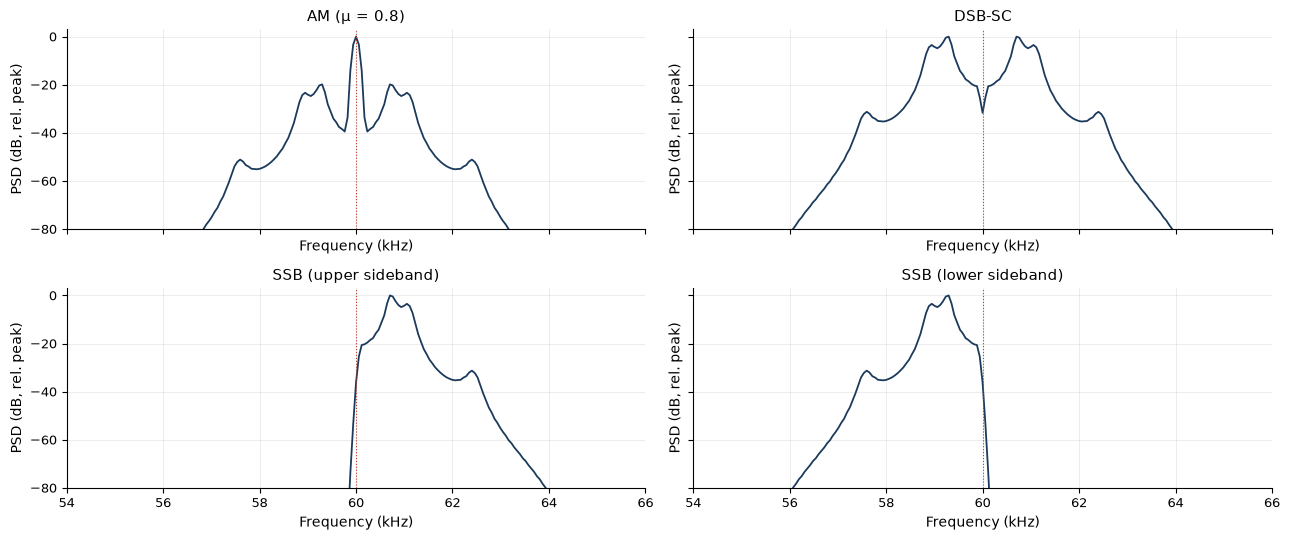

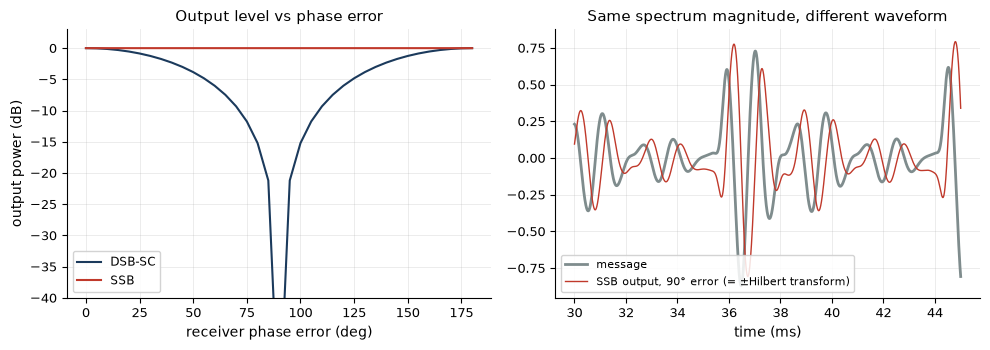

In [9]:
ma = hilbert(mp)                                          # analytic signal m + j m_hat
signals = {"AM (μ = 0.8)": (1 + 0.8 * mp) * np.cos(2 * np.pi * fc * t),
           "DSB-SC": mp * np.cos(2 * np.pi * fc * t),
           "SSB (upper sideband)": np.real(ma * np.exp(2j * np.pi * fc * t)),
           "SSB (lower sideband)": np.real(np.conj(ma) * np.exp(2j * np.pi * fc * t))}
f, axs = lk.fig((13, 5.5), 2, 2, sharex=True, sharey=True)
for ax, (name, sg) in zip(axs.ravel(), signals.items()):
    lk.psd(ax, sg, fs, 8192, scale=1e3, unit="kHz")
    ax.set_xlim(54, 66); ax.set_ylim(-80, 3); ax.axvline(60, color=lk.RED, ls=":", lw=0.8); ax.set_title(name)
lk.show(f)

lp = butter(6, 5000, fs=fs, output="sos")
phis = np.linspace(0, 180, 37)
rows_dsb, rows_ssb = [], []
for ph in np.deg2rad(phis):
    lo = 2 * np.cos(2 * np.pi * fc * t + ph)
    for sig, store in [(signals["DSB-SC"], rows_dsb), (signals["SSB (upper sideband)"], rows_ssb)]:
        y = sosfiltfilt(lp, sig * lo)
        store.append((np.mean(y ** 2) / np.mean(mp ** 2), np.dot(y, mp) / np.sqrt(np.dot(y, y) * np.dot(mp, mp))))
rows_dsb, rows_ssb = np.array(rows_dsb), np.array(rows_ssb)
f, ax = lk.fig("row2", 1, 2)
ax[0].plot(phis, lk.db(rows_dsb[:, 0] + 1e-6), label="DSB-SC"); ax[0].plot(phis, lk.db(rows_ssb[:, 0]), label="SSB")
ax[0].set_ylim(-40, 3); ax[0].set_xlabel("receiver phase error (deg)"); ax[0].set_ylabel("output power (dB)")
ax[0].legend(); ax[0].set_title("Output level vs phase error")
w_ = slice(int(0.03 * fs), int(0.045 * fs))
ax[1].plot(t[w_] * 1e3, mp[w_], color=lk.GRAY, lw=2, label="message")
y90 = sosfiltfilt(lp, signals["SSB (upper sideband)"] * 2 * np.cos(2 * np.pi * fc * t + np.pi / 2))
ax[1].plot(t[w_] * 1e3, y90[w_], color=lk.RED, lw=1, label="SSB output, 90° error (= ±Hilbert transform)")
ax[1].set_xlabel("time (ms)"); ax[1].legend(fontsize=8); ax[1].set_title("Same spectrum magnitude, different waveform")
lk.show(f)

**What you should see.** AM shows a carrier line and two mirror-image sidebands; DSB-SC the sidebands
only; SSB one sideband, half the bandwidth. On the left, DSB output falls as $\cos^2\phi$ and vanishes at 90°;
SSB output power does not change at all. On the right, SSB with a 90° error delivers the Hilbert
transform of the voice: a different waveform with the same magnitude spectrum, which the ear
(insensitive to phase) hears as the same voice. This tolerance is why SSB voice works with free-running oscillators.

## 4. FM: Bessel spectra and Carson's rule

FM puts the message in the instantaneous frequency: $s(t) = A\cos\!\big(2\pi f_ct + 2\pi k_f\!\int m\big)$,
with peak deviation $\Delta f = k_f\max|m|$ and, for a tone of frequency $f_m$, modulation index
$\beta = \Delta f/f_m$. A tone-modulated FM signal has spectral lines at $f_c + nf_m$ with amplitudes
$J_n(\beta)$; the carrier ($J_0$) vanishes at $\beta = 2.405$, a classic way to calibrate deviation.
**Carson's rule** $B_T \approx 2(\Delta f + W) = 2(\beta + 1)W$ captures about 98% of the power.

### Interactive: tone FM

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

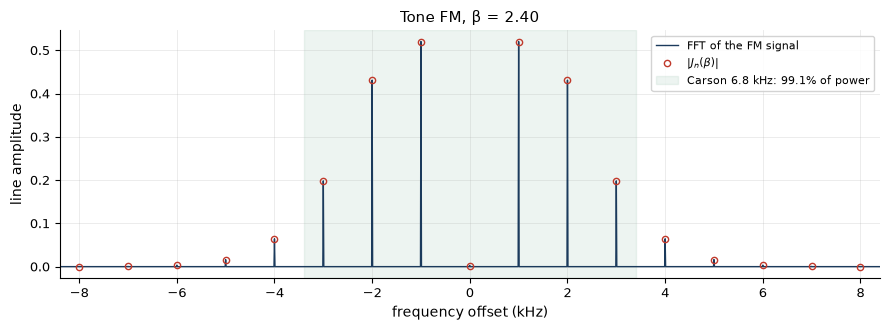

In [12]:
def fm_tone(beta=2.4, fm_hz=1000.0):
    fsb = 200_000
    tb = np.arange(int(0.2 * fsb)) / fsb
    z = np.exp(1j * beta * np.sin(2 * np.pi * fm_hz * tb))           # complex envelope
    Z = np.abs(np.fft.fftshift(np.fft.fft(z * np.hanning(len(z))))) / np.sum(np.hanning(len(z)))
    fr = np.fft.fftshift(np.fft.fftfreq(len(z), 1 / fsb))
    n = np.arange(-20, 21)
    f, ax = lk.fig("wide")
    ax.plot(fr / 1e3, Z, color=lk.NAVY, lw=1, label="FFT of the FM signal")
    ax.plot(n * fm_hz / 1e3, np.abs(jv(n, beta)), "o", color=lk.RED, mfc="none", label="$|J_n(\\beta)|$")
    bc = 2 * (beta + 1) * fm_hz
    inside = np.abs(n) * fm_hz <= bc / 2
    ax.axvspan(-bc / 2e3, bc / 2e3, color=lk.GREEN, alpha=0.08,
               label=f"Carson {bc / 1e3:.1f} kHz: {np.sum(jv(n[inside], beta) ** 2) * 100:.1f}% of power")
    ax.set_xlim(-(beta + 6) * fm_hz / 1e3, (beta + 6) * fm_hz / 1e3); ax.set_xlabel("frequency offset (kHz)")
    ax.set_ylabel("line amplitude"); ax.legend(fontsize=8); ax.set_title(f"Tone FM, β = {beta:.2f}")
    lk.show(f)

lk.interact(fm_tone, beta=lk.slider(2.4, 0.1, 10, 0.05, "β"), fm_hz=lk.slider(1000, 200, 5000, 100, "tone (Hz)"))

**What you should see.** Lines exactly on the Bessel predictions. At β = 2.40 the carrier line almost
vanishes. Small β (< 0.3) gives narrowband FM: a carrier and one pair of sidebands, like AM but in
quadrature. Carson's band always holds about 98% or more of the power.

### Try it yourself 4.1
FM broadcast uses 75 kHz peak deviation and the stereo multiplex extends to 53 kHz. What bandwidth (kHz)
does Carson's rule predict?

In [14]:
answer_4_1 = None
lk.check("4.1 Carson bandwidth of stereo FM (kHz)", answer_4_1, 2 * (75 + 53), atol=0.5)

[TODO] 4.1 Carson bandwidth of stereo FM (kHz): not attempted yet: replace the None with your answer

## 5. FM demodulation: discriminator and PLL

Two classic receivers recover the instantaneous frequency of the complex envelope $z(t)$:

* the **discriminator**: $\hat m \propto \arg\big(z[n]\,z^*[n-1]\big)$, the phase increment per sample
  (the digital equivalent of the Foster–Seeley and ratio detectors and of the quadrature detector);
* the **PLL**: lock a local oscillator to the signal; the loop's control voltage *is* the frequency.

Both are tested on our voice message with $\Delta f$ = 5 kHz (narrowband FM, as in two-way radio).

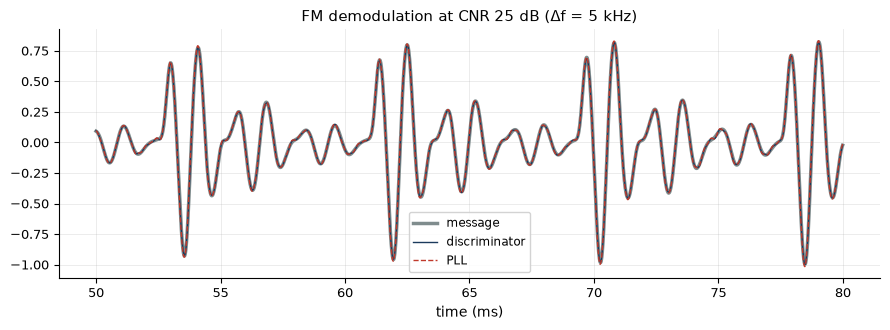

demodulator,output SNR (dB)
discriminator,35.9
"PLL (BnT = 0.3, Bn ≈ 29 kHz)",34.2


In [16]:
fsb = 96_000
mb = resample_poly(m, 2, 1)
tb = np.arange(len(mb)) / fsb
kf = 5000.0
z = np.exp(2j * np.pi * kf * np.cumsum(mb) / fsb)
zn = cl.awgn(z, 25, rng)
disc = np.angle(zn[1:] * np.conj(zn[:-1])) * fsb / (2 * np.pi * kf)
disc = np.r_[disc[0], disc]
# second-order PLL (phase detector = arg(z e^{-j theta}))
kp, ki = cl.loop_gains(0.3, 0.707)            # Bn = 0.3 x 96 kHz ≈ 29 kHz
theta, integ = 0.0, 0.0
pll = np.empty(len(zn))
for i, s_ in enumerate(zn):
    e = np.angle(s_ * np.exp(-1j * theta))
    integ += ki * e
    v = kp * e + integ
    theta += v
    pll[i] = v * fsb / (2 * np.pi * kf)
audio_lp = butter(6, 4000, fs=fsb, output="sos")
disc_a, pll_a = sosfiltfilt(audio_lp, disc), sosfiltfilt(audio_lp, pll)
f, ax = lk.fig("wide")
sl = slice(int(0.05 * fsb), int(0.08 * fsb))
ax.plot(tb[sl] * 1e3, mb[sl], color=lk.GRAY, lw=2.5, label="message")
ax.plot(tb[sl] * 1e3, disc_a[sl], color=lk.NAVY, lw=1, label="discriminator")
ax.plot(tb[sl] * 1e3, pll_a[sl], color=lk.RED, lw=1, ls="--", label="PLL")
ax.set_xlabel("time (ms)"); ax.legend(); ax.set_title("FM demodulation at CNR 25 dB (Δf = 5 kHz)")
lk.show(f)
def snr_aligned(y, ref, max_lag=8):
    """Output SNR after the best small delay and gain alignment (a loop's lag is not noise)."""
    best = -np.inf
    for d in range(-max_lag, max_lag + 1):
        yy, rr = y[200 + d:len(y) - 200 + d], ref[200:len(ref) - 200]
        g = np.dot(yy, rr) / np.dot(rr, rr)
        best = max(best, lk.db(np.sum((g * rr) ** 2) / np.sum((yy - g * rr) ** 2)))
    return best

snr_d, snr_p = snr_aligned(disc_a, mb), snr_aligned(pll_a, mb)
lk.table([["discriminator", snr_d], ["PLL (BnT = 0.3, Bn ≈ 29 kHz)", snr_p]], ["demodulator", "output SNR (dB)"], fmt={1: ".1f"})

**What you should see.** Both outputs overlay the message, and their output SNR is well above the 25 dB
input CNR (measured over the whole 96 kHz simulation band) because the audio filter rejects most of the
noise. Unlike the carrier-recovery loops of Lab 4, an FM-demodulating PLL must be *wide*: it has to follow
the instantaneous frequency, so its bandwidth must exceed the deviation plus the audio bandwidth.
Try `loop_gains(0.05, ...)` and watch the output SNR collapse as the loop lags behind the modulation.

## 6. The FM threshold

Above threshold, FM trades bandwidth for SNR: for a tone,
$\mathrm{SNR}_{\text{out}} = 3\beta^2(\beta+1)\,\mathrm{CNR}$, where CNR is measured in the Carson bandwidth,
a large improvement for wide deviation. Below about 10 dB CNR the noise occasionally wraps the phase
by $2\pi$, the discriminator outputs a spike (a **click**), and the output SNR collapses. AM has no
threshold but no improvement either: $\mathrm{SNR}_{\text{out}} \le \mathrm{CNR}$.

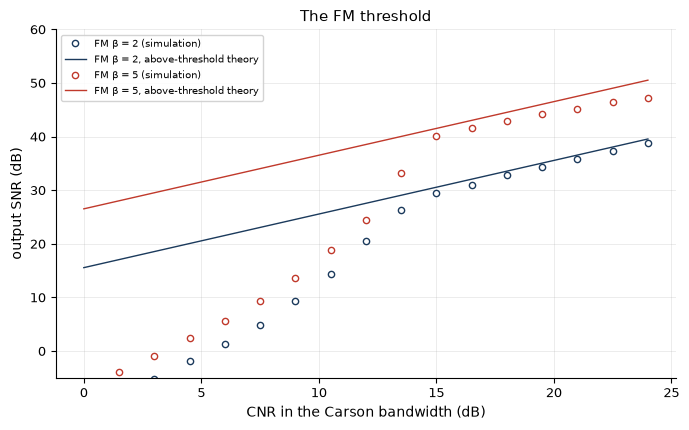

In [19]:
def fm_threshold(beta, cnrs, fm_=1000.0, n=200_000):
    fsx = 2 * (beta + 1) * fm_ * 4                              # simulate at 4x the Carson bandwidth
    tx = np.arange(n) / fsx
    msg = np.sin(2 * np.pi * fm_ * tx)
    zz = np.exp(1j * beta * np.sin(2 * np.pi * fm_ * tx - np.pi / 2) )
    bt = 2 * (beta + 1) * fm_
    out = []
    for cnr in cnrs:
        n0 = 1 / lk.undb(cnr) / bt * fsx                       # noise variance per sample
        y = zz + np.sqrt(n0 / 2) * (rng.standard_normal(n) + 1j * rng.standard_normal(n))
        d = np.angle(y[1:] * np.conj(y[:-1])) * fsx / (2 * np.pi * beta * fm_)
        D_ = np.fft.fft(np.r_[d[0], d])
        D_[np.abs(np.fft.fftfreq(n, 1 / fsx)) > 1.05 * fm_] = 0   # brick-wall audio filter, W = fm
        d = np.real(np.fft.ifft(D_))[2000:-2000]
        # least-squares fit of a sine AND cosine at fm: the discriminator's half-sample delay is not noise
        B = np.stack([np.sin(2 * np.pi * fm_ * tx), np.cos(2 * np.pi * fm_ * tx)], 1)[2000:-2000]
        coef, *_ = np.linalg.lstsq(B, d, rcond=None)
        fit = B @ coef
        out.append(lk.db(np.sum(fit ** 2) / np.sum((d - fit) ** 2)))
    return np.array(out)

cnrs = np.arange(0, 25, 1.5)
f, ax = lk.fig("ber")
for beta, col in [(2, lk.NAVY), (5, lk.RED)]:
    ax.plot(cnrs, fm_threshold(beta, cnrs), "o", color=col, mfc="white", label=f"FM β = {beta} (simulation)")
    ax.plot(cnrs, cnrs + lk.db(3 * beta ** 2 * (beta + 1)), "-", color=col, lw=1, label=f"FM β = {beta}, above-threshold theory")
ax.set_xlabel("CNR in the Carson bandwidth (dB)"); ax.set_ylabel("output SNR (dB)"); ax.legend(fontsize=7.5)
ax.set_title("The FM threshold"); ax.set_ylim(-5, 60)
lk.show(f)

**What you should see.** Above roughly 12–15 dB CNR the simulation follows the theory lines to within a
dB or two (the residual gap at β = 5 is the discrete discriminator's own approximation): β = 5 buys
about 10 dB more output SNR than β = 2 at the same CNR. Below threshold the curves bend down sharply, and
the wider the deviation, the more noise enters the wider band, so for a fixed received *power* wideband FM
reaches its threshold sooner. Chapter 4 makes the fair comparison with AM at equal power and noise density.

## 7. FM stereo: the multiplex signal

The 1961 FCC stereo standard had to stay compatible with mono receivers. The multiplex (MPX) baseband is

$$m_{\text{MPX}}(t) = 0.45\,(L+R) + 0.45\,(L-R)\cos(2\pi\,38\,\text{kHz}\,t) + 0.1\cos(2\pi\,19\,\text{kHz}\,t),$$

a mono-compatible sum channel, the difference channel as DSB-SC on 38 kHz, and a **pilot** at exactly half
the subcarrier frequency (plus RDS data at 57 kHz, not modelled here). The receiver doubles the pilot to
regenerate a phase-coherent 38 kHz carrier, demodulates L−R, and forms
$L = (S + D)/2$, $R = (S - D)/2$. We send a 1 kHz tone on the left and a 2.5 kHz tone on the right, FM-modulate
with 75 kHz peak deviation, add noise, demodulate and check the separation.

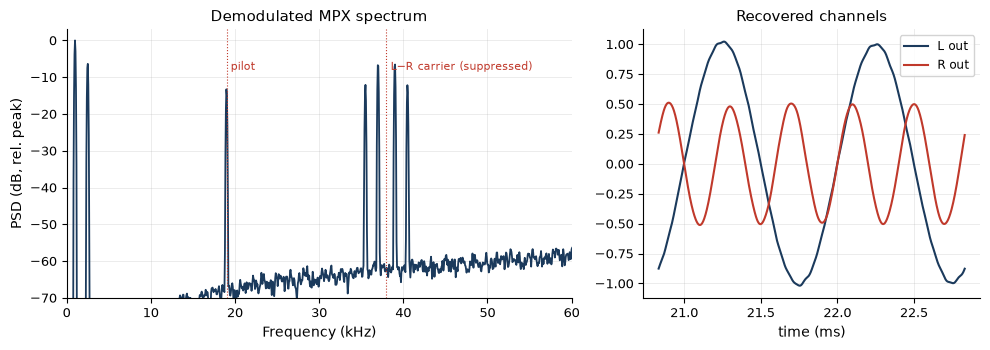

measurement,dB
left-to-right separation at 1 kHz,36.4
right-to-left separation at 2.5 kHz,39.8


In [22]:
fsm = 480_000
tm = np.arange(int(0.1 * fsm)) / fsm
L_ = np.sin(2 * np.pi * 1000 * tm)
R_ = 0.5 * np.sin(2 * np.pi * 2500 * tm)
pilot = np.cos(2 * np.pi * 19e3 * tm)
mpx = 0.45 * (L_ + R_) + 0.45 * (L_ - R_) * np.cos(2 * np.pi * 38e3 * tm) + 0.1 * pilot
zf = np.exp(2j * np.pi * 75e3 * np.cumsum(mpx) / fsm)
zr = cl.awgn(zf, 30, rng)
mpx_rx = np.angle(zr[1:] * np.conj(zr[:-1])) * fsm / (2 * np.pi * 75e3)
mpx_rx = np.r_[mpx_rx[0], mpx_rx]
# --- stereo decoder ---------------------------------------------------------------------
bp19 = butter(4, [18.5e3, 19.5e3], btype="band", fs=fsm, output="sos")
p19 = sosfiltfilt(bp19, mpx_rx)
p19 = p19 / np.sqrt(2 * np.mean(p19 ** 2))                       # unit-amplitude pilot
c38 = 2 * p19 ** 2 - 1                                            # cos(2x) = 2cos^2(x) - 1: the 38 kHz carrier
lp15 = butter(8, 15e3, fs=fsm, output="sos")
S = sosfiltfilt(lp15, mpx_rx) / 0.45
D = sosfiltfilt(lp15, 2 * mpx_rx * c38) / 0.45
L_hat, R_hat = (S + D) / 2, (S - D) / 2

def tone_level(x, f0):
    seg = x[5000:-5000]; tt_ = tm[5000:-5000]
    return np.abs(np.mean(seg * np.exp(-2j * np.pi * f0 * tt_))) * 2

sep_L = lk.db(tone_level(L_hat, 1000) ** 2 / tone_level(R_hat, 1000) ** 2)
sep_R = lk.db(tone_level(R_hat, 2500) ** 2 / tone_level(L_hat, 2500) ** 2)
f, ax = lk.fig("row2", 1, 2, gridspec_kw={"width_ratios": [1.5, 1]})
lk.psd(ax[0], mpx_rx, fsm, 8192, scale=1e3, unit="kHz"); ax[0].set_xlim(0, 60); ax[0].set_ylim(-70, 3)
for fx, lab in [(19, "pilot"), (38, "L−R carrier (suppressed)")]:
    ax[0].axvline(fx, color=lk.RED, ls=":", lw=0.8); ax[0].text(fx + 0.5, -8, lab, fontsize=8, color=lk.RED)
ax[0].set_title("Demodulated MPX spectrum")
sl = slice(10000, 10000 + 960)
ax[1].plot(tm[sl] * 1e3, L_hat[sl], label="L out"); ax[1].plot(tm[sl] * 1e3, R_hat[sl], label="R out")
ax[1].set_xlabel("time (ms)"); ax[1].legend(); ax[1].set_title("Recovered channels")
lk.show(f)
lk.table([["left-to-right separation at 1 kHz", sep_L], ["right-to-left separation at 2.5 kHz", sep_R]],
         ["measurement", "dB"], fmt={1: ".1f"})

**What you should see.** The MPX spectrum: L+R below 15 kHz, the pilot spike at 19 kHz, and L−R sidebands
around 38 kHz with no carrier. The decoder separates the channels by 30 dB or more (good broadcast
receivers achieve 40–50 dB); the separation depends on getting the regenerated 38 kHz phase exactly right,
which is why the pilot is phase-locked to the subcarrier at the transmitter.

## Key takeaways
* AM's envelope detector is trivially simple but wastes most of the power on the carrier; $RC$ must sit
  between the carrier period and the message period.
* DSB-SC needs coherent detection and fades with phase error; SSB halves the bandwidth and is tolerant
  of phase error (but not of frequency error).
* FM spectra follow Bessel functions; Carson's rule $2(\Delta f + W)$ holds about 98% of the power.
* FM trades bandwidth for SNR ($3\beta^2(\beta+1)$ above threshold) and fails abruptly below about 10 dB CNR.
* FM stereo is a beautiful compatible multiplex: pilot-aided coherent DSB-SC inside an FM channel.

## Going further (hardware: USRP B200 / GNU Radio)
* Record a local FM station with `gnuradio/gr01_spectrum_iq_capture.py --freq <station> --rate 480e3`
  and run Section 7's decoder on your capture (`cl.read_cfile`): first `np.angle(z[1:]*conj(z[:-1]))`,
  then the pilot, then L and R. Listen with `scipy.io.wavfile.write`.
* GNU Radio's `WBFM Receive` and `FM Demod` blocks implement Section 5; compare their output with yours.
* Tune to an aviation AM channel (118–137 MHz, where legal to receive) and apply the envelope detector.

## Exercises
1. **(Warm-up)** Prove that the AM envelope detector fails for μ > 1 and sketch the output.
2. **(Core)** Add 75 µs pre-emphasis/de-emphasis (North America; 50 µs in Europe) to Section 6 and measure
   the SNR gain for a voice-like message.
3. **(Core)** Generate SSB with the Weaver method (two quadrature mixing stages) and compare its sideband
   suppression with the Hilbert-transform (phasing) method when the Hilbert filter is truncated to 31 taps.
4. **(Stretch)** Add an RDS subcarrier (1187.5 b/s BPSK at 57 kHz, differential coding) to the MPX and
   decode it, recovering the 57 kHz carrier by tripling the pilot.

In [25]:
lk.summary()

[good] Lab 14 finished in 3.6 s. Self-checks: 0 passed, 0 failed, 2 still to do.